In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import wandb
import numpy as np
import cv2
import torch.nn.functional as F

# WandB login
wandb.login(key='0530bbf36999cf23c9faffc230ca42a929ee045b')
entity = "cs24s023-iitm-ac-in"
project = "garbage_classification_partB_full"

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/nagaraj/.netrc
wandb: Currently logged in as: cs24s023 (cs24s023-iitm-ac-in) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Using device: cuda


In [4]:
# Paths and classes
DATA_PATH = '/home/nagaraj/Garbage_classification_files/Garbage classification'
CLASSES = ['cardboard','glass','metal','paper','plastic','trash']

# Image transforms for fine-tuning
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

val_test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

# Load dataset
dataset = datasets.ImageFolder(DATA_PATH, transform=train_transform)
train_len = int(0.8 * len(dataset))
val_test_len = len(dataset) - train_len
train_data, val_test_data = random_split(dataset, [train_len, val_test_len])
val_len = test_len = val_test_len // 2
val_data, test_data = random_split(val_test_data, [val_len, test_len])

# Override transforms for val/test
val_data.dataset.transform = val_test_transform
test_data.dataset.transform = val_test_transform

# Dataloaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)


In [5]:
def freeze_layers(model, strategy):
    """
    Freeze layers according to fine-tuning strategy:
    strategy 1: Freeze all except last FC layer
    strategy 2: Freeze until layer4, fine-tune rest
    strategy 3: Train all layers (smaller LR)
    """
    if strategy == 1:
        for param in model.parameters():
            param.requires_grad = False
        for param in model.fc.parameters():
            param.requires_grad = True
    elif strategy == 2:
        for name, param in model.named_parameters():
            if "layer4" in name or "fc" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False
    elif strategy == 3:
        for param in model.parameters():
            param.requires_grad = True
    return model


In [6]:
def freeze_layers(model, strategy):
    """
    Freeze layers according to fine-tuning strategy:
    strategy 1: Freeze all except last FC layer
    strategy 2: Freeze until layer4, fine-tune rest
    strategy 3: Train all layers (smaller LR)
    """
    if strategy == 1:
        for param in model.parameters():
            param.requires_grad = False
        for param in model.fc.parameters():
            param.requires_grad = True
    elif strategy == 2:
        for name, param in model.named_parameters():
            if "layer4" in name or "fc" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False
    elif strategy == 3:
        for param in model.parameters():
            param.requires_grad = True
    return model


In [7]:
def train_finetune(strategy_num, epochs=10, lr=1e-4):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Load pre-trained ResNet50
    model = models.resnet50(pretrained=True)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, len(CLASSES))
    model = freeze_layers(model, strategy_num)
    model = model.to(device)
    
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    # WandB init
    wandb.init(project=project, entity=entity, name=f"strategy_{strategy_num}")
    
    best_val_acc = 0
    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0,0,0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            _, pred = out.max(1)
            correct += (pred==labels).sum().item()
            total += labels.size(0)
        train_acc = correct / total
        
        # Validation
        model.eval()
        correct_val, total_val = 0,0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs)
                _, pred = out.max(1)
                correct_val += (pred==labels).sum().item()
                total_val += labels.size(0)
        val_acc = correct_val / total_val
        
        wandb.log({"epoch": epoch, "train_acc": train_acc, "val_acc": val_acc, "train_loss": total_loss/len(train_loader)})
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f"best_model_strategy_{strategy_num}.pth")
    
    wandb.finish()
    return model


In [13]:
strategies = [1,2,3]
for s in strategies:
    print(f"Training strategy {s}")
    train_finetune(strategy_num=s, epochs=10, lr=1e-4)


Training strategy 1


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▂▃▃▄▅▆▆▇█
train_acc,▁▅▆▇▇▇████
train_loss,█▆▅▄▃▂▂▁▁▁
val_acc,▁▄▅▅▅▆▇▆██
epoch,9
train_acc,0.76645
train_loss,0.81943
val_acc,0.79051


Training strategy 2


/home/nagaraj/miniconda3/envs/TrajMIA/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/nagaraj/miniconda3/envs/TrajMIA/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


...

epoch,▁▂▃▃▄▅▆▆▇█
train_acc,▁▆▇▇██████
train_loss,█▃▂▂▁▁▁▁▁▁
val_acc,▃▅▁▅▆▆▅██▆
epoch,9
train_acc,0.97526
train_loss,0.0733
val_acc,0.92095


Training strategy 3


/home/nagaraj/miniconda3/envs/TrajMIA/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/nagaraj/miniconda3/envs/TrajMIA/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▂▃▃▄▅▆▆▇█
train_acc,▁▆▇▇▇███▇▇
train_loss,█▃▂▂▂▁▁▁▂▂
val_acc,▁▂▃▁▃██▅▄▃
epoch,9
train_acc,0.95596
train_loss,0.13984
val_acc,0.88538


In [14]:
def evaluate_model(strategy_num):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = models.resnet50(pretrained=True)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, len(CLASSES))
    model.load_state_dict(torch.load(f"best_model_strategy_{strategy_num}.pth"))
    model = model.to(device)
    model.eval()
    
    all_preds, all_labels, all_imgs = [], [], []
    correct_test, total_test = 0,0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            _, pred = out.max(1)
            correct_test += (pred==labels).sum().item()
            total_test += labels.size(0)
            all_preds.append(pred.cpu())
            all_labels.append(labels.cpu())
            all_imgs.append(imgs.cpu())
    test_acc = correct_test / total_test
    print(f"Strategy {strategy_num} Test Accuracy: {test_acc*100:.2f}%")
    
    # 10x3 prediction grid
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    all_imgs = torch.cat(all_imgs)
    num_images = min(30, len(all_imgs))
    fig, axes = plt.subplots(10,3, figsize=(10,30))
    axes = axes.flatten()
    for i in range(num_images):
        img = all_imgs[i].permute(1,2,0).numpy()
        axes[i].imshow(img)
        axes[i].set_title(f"Pred: {CLASSES[all_preds[i]]}\nTrue: {CLASSES[all_labels[i]]}")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()


In [15]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()
    
    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()
        for name, module in self.model.named_modules():
            if name == self.target_layer:
                module.register_forward_hook(forward_hook)
                module.register_backward_hook(backward_hook)
    
    def generate_cam(self, input_img, target_class):
        self.model.zero_grad()
        output = self.model(input_img.unsqueeze(0))
        loss = output[0,target_class]
        loss.backward()
        weights = torch.mean(self.gradients, dim=(2,3), keepdim=True)
        cam = torch.sum(weights*self.activations, dim=1)[0]
        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        cam = cam.cpu().numpy()
        cam = cv2.resize(cam, (input_img.shape[2], input_img.shape[1]))
        return cam


In [16]:
def visualize_gradcam(strategy_num, img_idx=0):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = models.resnet50(pretrained=True)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, len(CLASSES))
    model.load_state_dict(torch.load(f"best_model_strategy_{strategy_num}.pth"))
    model.to(device).eval()
    
    gradcam = GradCAM(model, target_layer="layer4")
    img, label = test_data[img_idx]
    img_tensor = img.to(device)
    
    cam = gradcam.generate_cam(img_tensor, target_class=label)
    img_np = img.permute(1,2,0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max()-img_np.min())
    heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)/255
    overlay = heatmap*0.4 + img_np*0.6
    
    plt.figure(figsize=(6,6))
    plt.imshow(overlay)
    plt.title(f"Strategy {strategy_num} - True: {CLASSES[label]}")
    plt.axis("off")
    plt.show()


Grad-CAM for strategy 1


/home/nagaraj/miniconda3/envs/TrajMIA/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/nagaraj/miniconda3/envs/TrajMIA/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/nagaraj/miniconda3/envs/TrajMIA/lib/python3.11/site-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backw

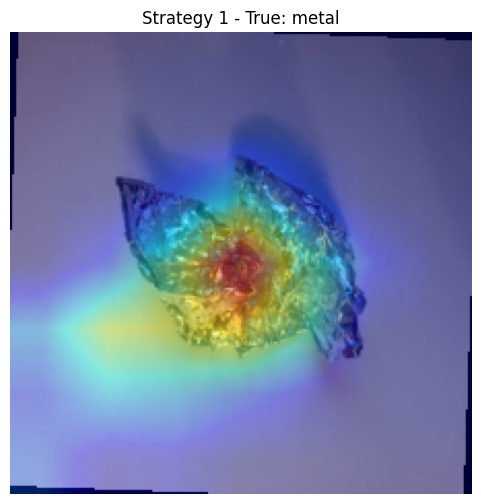

Grad-CAM for strategy 2


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].


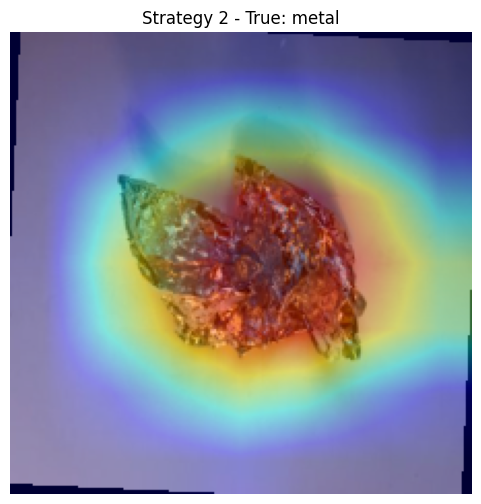

Grad-CAM for strategy 3


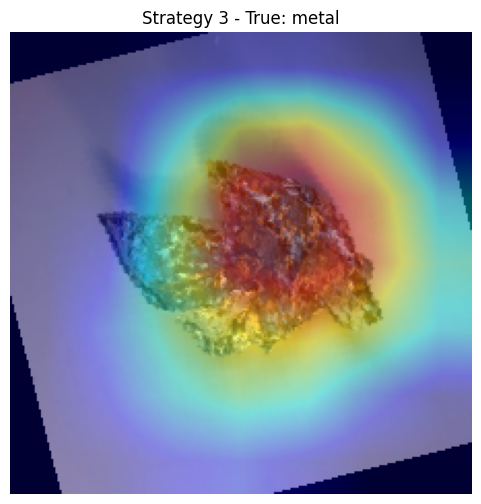

In [17]:
for s in strategies:
    print(f"Grad-CAM for strategy {s}")
    visualize_gradcam(strategy_num=s, img_idx=0)
